# Introduction

As described in my previous assignment, for my semester project, I use the FNSPID dataset [1]. This dataset consists of tens of millions of financial news articles in a csv. For example, the excerpt below is found in one of the articles:

"Agilent Technologies reported adjusted earnings of 404 million or 1.38 per share for the period. Analysts on average had expected the company to earn 1.34 per share, according to figures compiled by Thomson Reuters."

My research question is the following: Is it possible to train a transformer that completes sentences in the fashion of a financial news article?

There are two main goals in this assignment: 
- Turn text containing in a large csv into tokens that can be ingested by a language model.
- Build a transformer architecture that can perform next word prediction.

# Exploratory Data Analysis

In [5]:
import pandas as pd
import numpy as np
import os
import tiktoken
import math
import numpy as np
import time
import datetime
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

torch.set_float32_matmul_precision('high')
torch.manual_seed(137)
torch.cuda.manual_seed_all(137)


The dataset is 22GB. Way too big for my computer's memory! For that reason, we use a sample of 100,000 rows for the exploratory data analysis. 

In [ ]:
df_sample = pd.read_csv("FNSPID_data\\nasdaq_external_data.csv", nrows=100000)

In [ ]:
df_sample.columns

Index(['Unnamed: 0', 'Date', 'Article_title', 'Stock_symbol', 'Url',
       'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary',
       'Textrank_summary', 'Lexrank_summary'],
      dtype='object')

There are fairly few columns in the dataset. For that reason, we can afford to inspect them one by one. But first, let's check whether any of the columns have missing values.

In [ ]:
# Count the number of missing by column
missing = df_sample.isnull().sum()
print(missing)

Unnamed: 0               0
Date                     0
Article_title            0
Stock_symbol             0
Url                      0
Publisher           100000
Author              100000
Article                  0
Lsa_summary              1
Luhn_summary             0
Textrank_summary         0
Lexrank_summary          0
dtype: int64


All 100,000 samples having Publisher and Author set to Null. We can ignore those two fields.

In [ ]:
df_sample['Unnamed: 0']

0            0.0
1            1.0
2            2.0
3            3.0
4            4.0
          ...   
99995    99995.0
99996    99996.0
99997    99997.0
99998    99998.0
99999    99999.0
Name: Unnamed: 0, Length: 100000, dtype: float64

This first column is the index column, which is not needed. We can ignore it.

In [ ]:
df_sample['Date'].head(5)

0    2023-12-16 23:00:00 UTC
1    2023-12-12 00:00:00 UTC
2    2023-12-12 00:00:00 UTC
3    2023-12-07 00:00:00 UTC
4    2023-12-07 00:00:00 UTC
Name: Date, dtype: object

This column indicates the date of publication of the article. This will be useful for the train/validation/split: we can do a temporal split, with the oldest articles in the train data, to avoid leakage.

In [ ]:
df_sample['Article_title'].head(5)

0    Interesting A Put And Call Options For August ...
1    Wolfe Research Initiates Coverage of Agilent T...
2    Agilent Technologies Reaches Analyst Target Price
3    Agilent (A) Enhances BioTek Cytation C10 With ...
4    Pre-Market Most Active for Dec 7, 2023 : SQQQ,...
Name: Article_title, dtype: object

This column contains the titles of the articles. Although this is text, we will focus on training the model to write the body of articles rather than their title, so we drop that column.

In [ ]:
df_sample['Stock_symbol'].unique()

array(['A', 'AA', 'AAAU', 'AACG', 'AADR', 'AAL', 'AAMC', 'AAME', 'AAN',
       'AAOI', 'AAON', 'AAP', 'AAPL', 'AAT', 'AAU', 'AAXJ', 'AB', 'ABBV',
       'ABCB', 'ABEO', 'ABEQ', 'ABEV', 'ABG', 'ABIO', 'ABM', 'ABR', 'ABT',
       'ABUS', 'AC', 'ACA', 'ACAD', 'ACB', 'ACCO', 'ACEL', 'ACES', 'ACGL',
       'ACGLO', 'ACHC', 'ACHV', 'ACI', 'ACIO', 'ACIU', 'ACIW', 'ACLS',
       'ACM', 'ACMR', 'ACN', 'ACNB', 'ACOR', 'ACP', 'ACRE', 'ACRS',
       'ACRX', 'ACSI', 'ACST', 'ACT', 'ACTG', 'ACU', 'ACV', 'ACWI',
       'ACWV', 'ACWX', 'ADAP', 'ADBE', 'ADC', 'ADCT', 'ADES', 'ADI',
       'ADIL', 'ADM', 'ADMA', 'ADME', 'ADNT', 'ADP', 'ADPT', 'ADSK',
       'ADT', 'ADTN', 'ADTX', 'ADUS', 'ADVM', 'ADX', 'ADXN', 'ADXS', 'AE',
       'AEE', 'AEF', 'AEFC', 'AEG', 'AEHR', 'AEIS', 'AEL', 'AEM', 'AEMD',
       'AEO', 'AEP', 'AER', 'AES', 'AESR', 'AEY', 'AEYE', 'AEZS', 'AFB',
       'AFG', 'AFGB', 'AFGC', 'AFGD', 'AFIF', 'AFK', 'AFL', 'AFLG',
       'AFMC', 'AFMD', 'AFSM', 'AFT', 'AFTY', 'AFYA', 'AG', 'AGBA',
 

That field contains the stock ticker associated with each article. We initially considered using this field for the train/test/validation split, but decided that a temporal split is sufficient. Hence, we drop the ticker field.

In [ ]:
df_sample['Url'].head(5)

0    https://www.nasdaq.com/articles/interesting-a-...
1    https://www.nasdaq.com/articles/wolfe-research...
2    https://www.nasdaq.com/articles/agilent-techno...
3    https://www.nasdaq.com/articles/agilent-a-enha...
4    https://www.nasdaq.com/articles/pre-market-mos...
Name: Url, dtype: object

The url of articles are not useful to our model, so we drop it.

In [ ]:
df_sample['Article'][0]

'Investors in Agilent Technologies, Inc. (Symbol: A) saw new options begin trading this week, for the August 2024 expiration. One of the key inputs that goes into the price an option buyer is willing to pay, is the time value, so with 241 days until expiration the newly trading contracts represent a possible opportunity for sellers of puts or calls to achieve a higher premium than would be available for the contracts with a closer expiration. At Stock Options Channel, our YieldBoost formula has looked up and down the A options chain for the new August 2024 contracts and identified one put and one call contract of particular interest.\nThe put contract at the $125.00 strike price has a current bid of $4.50. If an investor was to sell-to-open that put contract, they are committing to purchase the stock at $125.00, but will also collect the premium, putting the cost basis of the shares at $120.50 (before broker commissions). To an investor already interested in purchasing shares of A, tha

'Article' is the key field of our dataset. It contains the text of the financial article. This will be the field we will be using to train our language model. The example above is the text coming from one article. The full dataset contains millions like these.


As we can see below, the remaining four fields are different types of summaries of the main article. This would not necessarily add value to our training, and we already have a gigantic dataset, so we ignore those fields.

In [ ]:
df_sample['Lsa_summary'][0]


"Because the $125.00 strike represents an approximate 10% discount to the current trading price of the stock (in other words it is out-of-the-money by that percentage), there is also the possibility that the put contract would expire worthless. Of course, a lot of upside could potentially be left on the table if A shares really soar, which is why looking at the trailing twelve month trading history for Agilent Technologies, Inc., as well as studying the business fundamentals becomes important. Below is a chart showing A's trailing twelve month trading history, with the $150.00 strike highlighted in red: Considering the fact that the $150.00 strike represents an approximate 8% premium to the current trading price of the stock (in other words it is out-of-the-money by that percentage), there is also the possibility that the covered call contract would expire worthless, in which case the investor would keep both their shares of stock and the premium collected."

In [ ]:
df_sample['Luhn_summary'][0]


'The current analytical data (including greeks and implied greeks) suggest the current odds of that happening are 77%. Below is a chart showing the trailing twelve month trading history for Agilent Technologies, Inc., and highlighting in green where the $125.00 strike is located relative to that history: Turning to the calls side of the option chain, the call contract at the $150.00 strike price has a current bid of $8.10. The current analytical data (including greeks and implied greeks) suggest the current odds of that happening are 53%.'

In [ ]:
df_sample['Textrank_summary'][0]

"Below is a chart showing the trailing twelve month trading history for Agilent Technologies, Inc., and highlighting in green where the $125.00 strike is located relative to that history: Turning to the calls side of the option chain, the call contract at the $150.00 strike price has a current bid of $8.10. Below is a chart showing A's trailing twelve month trading history, with the $150.00 strike highlighted in red: Considering the fact that the $150.00 strike represents an approximate 8% premium to the current trading price of the stock (in other words it is out-of-the-money by that percentage), there is also the possibility that the covered call contract would expire worthless, in which case the investor would keep both their shares of stock and the premium collected. On our website under the contract detail page for this contract, Stock Options Channel will track those odds over time to see how they change and publish a chart of those numbers (the trading history of the option cont

In [ ]:
df_sample['Lexrank_summary'][0]

"At Stock Options Channel, our YieldBoost formula has looked up and down the A options chain for the new August 2024 contracts and identified one put and one call contract of particular interest. Should the contract expire worthless, the premium would represent a 3.60% return on the cash commitment, or 5.45% annualized — at Stock Options Channel we call this the YieldBoost. Below is a chart showing A's trailing twelve month trading history, with the $150.00 strike highlighted in red: Considering the fact that the $150.00 strike represents an approximate 8% premium to the current trading price of the stock (in other words it is out-of-the-money by that percentage), there is also the possibility that the covered call contract would expire worthless, in which case the investor would keep both their shares of stock and the premium collected."

In [ ]:
df_sample['article_length'] = df_sample['Article'].str.len()

print("Length in characters of longest article: ", df_sample['article_length'].max())
print("Length in characters of shortest article: ", df_sample['article_length'].min())
print("Length in characters of median article: ", int(df_sample['article_length'].median()))

Length in characters of longest article:  272968
Length in characters of shortest article:  1
Length in characters of median article:  3955


In this last cell, we see that the length of articles range between 1 character to over 200,000 characters, with a median of about 4,000 characters. 

One-character articles are not very useful and should be removed. We do that in the next section.

# Data Transformations

In this section, we transform the raw data into train, test, and validation datasets.

## Load the data

Following the Exploratory Data Analysis above, we will use only two columns: 'Date' for the train/validation/test split and 'Article' for the text data.

In [ ]:
df = pd.read_csv("FNSPID_data\\nasdaq_external_data.csv", usecols=['Date','Article'])
# Force the correct types
df['Date'] = pd.to_datetime(df['Date'])
df['Article'] = df['Article'].astype(str)

## Cleanup the Dataset

We delete a row if any of the following two conditions is true.
- Any of the two columns of interest is missing.
- The length of Article is less than 100 characters.

The character threshold is selected to be 100, because anything less than that would be too short to contain financial news information, and is probably something like an error message, a disclaimer, or some other type of brief message we want to ignore.


In [ ]:

df['Missing'] = df.apply(lambda x: 1 if (pd.isnull(x['Date']) or
                                         pd.isnull(x['Article']) or
                                         len(x['Article']) < 100) else 0,
                         axis=1)
missing_count = df['Missing'].value_counts()[1]
print(f"There are {missing_count} missing values in the dataset.")

There are 11811438 missing values in the dataset.


In [ ]:
df = df.dropna(subset=['Date', 'Article'])
df = df.drop(columns=['Missing'])

In [ ]:
print("After removing missings, there are ", len(df),
      "rows remaining in the dataset.")

After removing missings, there are  15549299 rows remaining in the dataset.


We now have about 15 millions of articles. Let's split them into training, validation, and test sets.

## Train-Validation-Test Split

For timestamped data, it is always good to have held-out data be as of a later date than the training data. This way, there cannot be leakage of information from the held-out sets to the training set.

We split the rows according to the following rule:
- Articles published in 2021 and before are in the training dataset.
- Articles published in 2022 are in the validation dataset.
- Articles published in 2023 are in the test dataset.  

In [ ]:

df['Set'] = np.where(df['Date'] >= '2023-01-01', 'Test',
                     np.where(df['Date'] >= '2022-01-01', 'Validation',
                              'Train'))

train = df[df['Set'] == 'Train']
train = train.drop(columns=['Date','Set'])

validation = df[df['Set'] == 'Validation']
validation = validation.drop(columns=['Date','Set'])

test = df[df['Set'] == 'Test']
test = test.drop(columns=['Date','Set'])

print("The train dataset contains", len(train), "articles.")
print("The validation dataset contains", len(validation), "articles.")
print("The test dataset contains", len(test), "articles.")

The train dataset contains 14314758 articles.
The validation dataset contains 280354 articles.
The test dataset contains 954187 articles.


Let's take a peek at each dataset to make sure everything looks reasonable

In [ ]:
train.head()

,Article
923,"MADRID, Dec 30 (Reuters) - Alcoa AA.N has line..."
924,"Adds quote, detail, background\nOSLO, Dec 30 (..."
925,"Updates prices, adds comment\nDec 30 (Reuters)..."
926,"InvestorPlace - Stock Market News, Stock Advic..."
927,"MADRID, Dec 29 (Reuters) - Alcoa Corp AA.N rea..."


In [ ]:
validation.head()

,Article
304,Agilent Technologies (A) is one of the stocks ...
305,Alphabet’s GOOGL division Google is consistent...
306,Airbnb ABNB has made an announcement to stop p...
307,Looking at the universe of stocks we cover at ...
308,Agilent Technologies (A) could be a solid choi...


In [ ]:
test.head()

,Article
0,"Investors in Agilent Technologies, Inc. (Symbo..."
1,"Fintel reports that on December 13, 2023, Wolf..."
2,"In recent trading, shares of Agilent Technolog..."
3,Agilent Technologies A is enhancing its BioTek...
4,The NASDAQ 100 Pre-Market Indicator is up 70.2...


## Convert Text to Tokens


Our model needs a tokenizer to convert text into tokens and vice versa. We will use the tiktoken library to do this. We first convert each dataset to a long string of text. Next, we apply the tokenizer to convert those long strings into lists of integers (each integer representing a token). Since this is a very compute-intensive process for such a large dataset we do the following things:
- Break-up the text into chunks
- Repeatedly save and load from file to avoid having to run again if it crashes.

In [ ]:
def save_string_to_file(content, filename):
    with open( os.path.join("FNSPID_transformed", filename), 'w',
              encoding='utf-8') as file:
        file.write(content)

In [ ]:
def load_string_from_file(filename):
    with open(os.path.join("FNSPID_transformed", filename), 'r',
              encoding='utf-8') as file:
        content = file.read()
    return content

In [ ]:
# Combine the entire train['Article'] into a single string, and save
# as .npy file
train_articles = ' '.join(train['Article'].tolist())
save_string_to_file(train_articles, 'train_articles.txt')


In [ ]:
# Combine the entire validation['Article'] into a single string, and save
# as .npy file
validation_articles = ' '.join(validation['Article'].tolist())
save_string_to_file(validation_articles, 'validation_articles.txt')

In [ ]:
# Combine the entire test['Article'] into a single string, and save as
# .npy file
test_articles = ' '.join(test['Article'].tolist())
save_string_to_file(test_articles, 'test_articles.txt')

To tokenize, we use the freely available tiktoken tokenizer library, which implements the tokenizer used by OpenAI for GPT-2. Since the dataset is so big, we must break it up into chunks (we run out of RAM otherwise).

In [ ]:
# Open-source tokenizer
tokenizer = tiktoken.get_encoding("gpt2")

In [ ]:
def tokenize_in_chunks(split, tokenizer, chunk_size=100000000,
                       output_dir="FNSPID_transformed", max_chunks=50):
    os.makedirs(output_dir, exist_ok=True)
    total_token_cnt = 0
    chunk_id = 0
    with open(f"{split}_articles.txt", 'r', encoding='utf-8') as f:
        while True:
            text_chunk = f.read(chunk_size)
            if not text_chunk or chunk_id >= max_chunks:
                break
            tokens = tokenizer.encode(text_chunk)
            output_file = os.path.join(output_dir,
                                       f'{split}_tokens_chunk_{chunk_id}.npy')
            np.save(output_file, tokens)
            cnt = len(tokens)
            print(f"Created and saved chunk {chunk_id}, token cnt = {cnt}")
            chunk_id += 1
            total_token_cnt += len(tokens)

    print(f"Completed {chunk_id} chunks, created a total of {total_token_cnt}")
    return chunk_id

Each chunk contains 100MB worth of text.

In [ ]:
chunk_size_100_mb = 100000000 # 100MB worth of text per chunk

In [ ]:
tokenize_in_chunks("train", chunk_size=chunk_size_100_mb,
                   tokenizer=tokenizer, max_chunks=math.inf)

In [ ]:
tokenize_in_chunks("validation", chunk_size=chunk_size_100_mb,
                   tokenizer=tokenizer, max_chunks=1)

In [ ]:
tokenize_in_chunks("test", chunk_size=chunk_size_100_mb,
                   tokenizer=tokenizer, max_chunks=1)

We fully converted the training set into chunks of tokens. The more training data we have, the better our model might become. The same is not necessarily true for the validation and test datasets. Once they are big enough, there is little to be gained from using even more tokens to calculate hold-out metrics. Hence, we only tokenize one chunk of the validation and one chunk of the test set. This still represents 100MB of text each, and it saves us about an hour of run time. In the end, we have the following.

The training data contains 82 chunks, for a total of 2,759,656,441 tokens.

The validation data contains 1 chunk, for a total of 22,679,859 tokens.

The test data contains 1 chunk, for a total of 22,637,887 tokens.

# Modeling

We now define a transformer architecture capable of language modeling. This architecture is loosely inspired by Andrej Karpathy's Youtube series on neural networks [2] and by the Attention is All You Need paper [3]. A transformer consists of a series of "blocks". Each block has two components: one attention layer consisting of parallel self-attention heads, and one multi-layer-perceptron. Contrarily, to the Attention Is All You Need paper, which was focused on machine translation, we implement a decoder-only model (no encoder).

The first step is to define a multi-head attention module. The number of heads is parametrized, will enable us to change it later if we want. The dimension of word embeddings is also parametrized. We use causal attention since we are doing next word prediction. That is, the prediction for one token does not have access to subsequent tokens in the sequence, even if they are known at runtime.  

In [6]:
class AttentionModule(nn.Module):

    def __init__(self, num_head, embedding_size):
        super().__init__()
        self.num_head = num_head
        self.embedding_size = embedding_size
        assert self.embedding_size % self.num_head == 0
        self.qkv_matrices = nn.Linear(self.embedding_size,
                                      3 * self.embedding_size)
        self.qkv_projections = nn.Linear(self.embedding_size,
                                         self.embedding_size)

    def forward(self, x):
        batch_size, seq_len, q_dim = x.size()
        qkv = self.qkv_matrices(x)
        q, k, v = qkv.split(self.embedding_size, dim=2)
        k = k.view(batch_size, seq_len,
                   self.num_head, q_dim // self.num_head).transpose(1, 2)
        q = q.view(batch_size, seq_len,
                   self.num_head, q_dim // self.num_head).transpose(1, 2)
        v = v.view(batch_size, seq_len,
                   self.num_head, q_dim // self.num_head).transpose(1, 2)
        attn = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        attn = attn.transpose(1, 2).contiguous()
        attn = attn.view(batch_size, seq_len, q_dim)
        return self.qkv_projections(attn)


This is the second half of each attention block, the multi-layer percentron (MLP). Each MLP has only two layers, with one GELU activation function in the middle.

In [ ]:
class MultiLayerPerceptron(nn.Module):

    def __init__(self, embedding_size):
        super().__init__()
        self.linear1 = nn.Linear(embedding_size, 4 * embedding_size)
        self.activation = nn.GELU(approximate='tanh')
        self.linear2 = nn.Linear(4 * embedding_size, embedding_size)

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        return x

We put together the attention module and the MLP to create one transformer block. Layer normalization is applied to the input of each module. Moreover, the model has "full residual connections", in the sense that the input of every layer is the sum of the output of the previous layer plus the "unaltered" word embeddings.  

In [ ]:
class TransformerBlock(nn.Module):

    def __init__(self, num_head, embedding_size):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(embedding_size)
        self.multi_head_attention = AttentionModule(
                                        num_head=num_head,
                                        embedding_size=embedding_size
                                        )
        self.layer_norm2 = nn.LayerNorm(embedding_size)
        self.multi_layer_perceptron = MultiLayerPerceptron(
                                        embedding_size=embedding_size
                                        )

    def forward(self, x):
        x = x + self.multi_head_attention(self.layer_norm1(x))
        x = x + self.multi_layer_perceptron(self.layer_norm2(x))
        return x

Putting everything together, our transformer is a stack of transformer blocks. Its forward pass goes as follows:
- Turn the token indexing into word embeddings.
- Add positional encodings (a representation of the position of each token in the sequence).
- Go through all transformer blocks.
- Unembed by applying a linear layer to the final output to project back to the vocabulary space. 

We also incorporate our loss function into the forward pass. Since next word prediction is fundamentally a classification problem, we use cross-entropy loss.

In [ ]:
class Transformer(nn.Module):

    def __init__(self, seq_len, vocab_size, block_cnt, num_head,
                 embedding_size):
        super().__init__()
        self.seq_len = seq_len
        self.vocab_size = vocab_size
        self.block_cnt = block_cnt
        self.num_head = num_head
        self.embedding_size = embedding_size

        self.positional_embeddings = nn.Embedding(self.seq_len,
                                                  self.embedding_size)
        self.word_embeddings = nn.Embedding(self.vocab_size,
                                            self.embedding_size)
        self.blocks = nn.Sequential(*[TransformerBlock(num_head=num_head,
                embedding_size=embedding_size) for _ in range(self.block_cnt)])
        self.layer_norm = nn.LayerNorm(self.embedding_size)
        self.unembed = nn.Linear(self.embedding_size,
                                 self.vocab_size, bias=False)
        self.word_embeddings.weight = self.unembed.weight

        self.apply(self.initialize_weights)

    def initialize_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.0144 / self.block_cnt ** 0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, token_ids, labels=None):
        batch_size, seq_len = token_ids.size()
        position_idxs = torch.arange(0, seq_len, dtype=torch.long,
                                     device=token_ids.device)
        p = self.positional_embeddings(position_idxs)
        x = self.word_embeddings(token_ids) + p
        x = self.blocks(x)
        x = self.layer_norm(x)
        logits = self.unembed(x)
        loss = None
        if labels is not None:
            input = logits.view(-1, logits.size(-1))
            target = labels.view(-1)
            loss = F.cross_entropy(input, target)
        return logits, loss



The last step for this assignment is to prepare a custom data loader. Since we split our training tokens into chunks, it it easier to build a custom data loader rather than using pytorch's built-in data loader. 

The data loader below iterates over all token chunks of each given split (train, validation, or split). Moreover, the .npy files full of token IDs that we have prepared earlier are simply lists of integers. This data loader converts the lists into tensors of a parametrized batch size and sequence length. Our transformer will be able to ingest such tensors during training.    

In [ ]:
class DataLoader:
    def __init__(self, batch_size, seq_len, split):
        self.batch_size = batch_size
        self.seq_len = seq_len
        self.split = split
        splits = ['train', 'validation', 'test']
        assert split in splits, f"invalid split: {split}"
        files = os.listdir(data_dir)
        files = [filename for filename in files if ((split in filename) \
                                      and filename.endswith(".npy"))]
        files = [os.path.join(data_dir, s) for s in files]
        self.shards = files
        self.shard_cnt = len(self.shards)
        assert len(files) >= 1, f"found {len(files)} files for split {split}"
        self.current_shard = 0
        self.choose_shard_and_position()

    def load_tokens(self, filename):
        # Long array of integers
        idxs_array = np.load(filename)
        idxs_array = idxs_array.astype(np.int32)
        # Long tensor of integers
        idxs_tensor = torch.tensor(idxs_array, dtype=torch.long)
        return idxs_tensor

    def next_batch(self):
        batch_size, seq_len = self.batch_size, self.seq_len
        start = self.current_position
        end = self.current_position+batch_size*seq_len+1
        buf = self.tokens[start:end]
        x = (buf[:-1]).view(batch_size, seq_len)
        y = (buf[1:]).view(batch_size, seq_len)
        self.current_position += batch_size * seq_len 
        if self.current_position + \
         (batch_size * seq_len + 1) > len(self.tokens):
            # The current shard is exhausted, so we need to load the next one
            self.choose_shard_and_position()
        return x, y

    def choose_shard_and_position(self):
        if self.split == "train":
            # For training, we want to move from one shard to the other, and
            # randomize the position
            self.current_shard = (self.current_shard + 1) % self.shard_cnt
            self.current_position = np.random.randint(0, self.batch_size - 1)
        else:
            # For validation and testing, we always want to start from the
            # beginning of the first shard
            self.current_shard = 0
            self.current_position = 0
        self.tokens = self.load_tokens(self.shards[self.current_shard])



In [15]:
vocab_size = 50304
block_cnt = 12
seq_len = 32
batch_size = 8
total_batch_size = 256
num_head = 12
embedding_size = 768
max_learning_rate = 1e-4
max_steps = 1000

data_dir = "FNSPID_transformed"
device = "cuda"
printing_freq = 100 # Print results every X steps
saving_model_freq = 200 # Saves torch model every X steps


In [ ]:

train_loader = DataLoader(batch_size=batch_size, seq_len=seq_len,
                          split="train")
validation_loader = DataLoader(batch_size=batch_size, seq_len=seq_len,
                               split="validation")

model = Transformer(seq_len=seq_len, vocab_size=vocab_size,
                    block_cnt=block_cnt, num_head=num_head,
                    embedding_size=embedding_size)
model.to(device)

params = {param for _, param in model.named_parameters() if param.requires_grad}
optimizer = torch.optim.Adam(params, lr=max_learning_rate, betas=(0.9, 0.99))

# Prefix for saving artifacts
now = datetime.datetime.now()
now_str = now.strftime("%Y-%m-%d_%H-%M-%S")

# Create a log
log_dir = "log"
os.makedirs(log_dir, exist_ok=True)
log_file = os.path.join(log_dir, f"log.txt")
with open(log_file, "w") as f:
    pass # clears contents

training_loss = [] # (step, train_loss)
validation_loss = [] # (step, valid_loss)
assert total_batch_size % (batch_size * seq_len) == 0
grad_cumul_steps = total_batch_size // (batch_size * seq_len)

for step in range(max_steps):
    last_step = (step == max_steps - 1)

    # Evaluate in validation dataset every printing_freq steps
    if step % printing_freq == 0 or last_step:
        model.eval()
        validation_loader.choose_shard_and_position()
        with torch.no_grad():
            validation_loss_cumul = 0.0
            val_loss_steps = 20
            for _ in range(val_loss_steps):
                x, y = validation_loader.next_batch()
                x, y = x.to(device), y.to(device)
                with torch.autocast(device_type=device, dtype=torch.bfloat16):
                    logits, loss = model(x, y)
                loss = loss / val_loss_steps
                validation_loss_cumul += loss.detach()
        validation_update_msg = f"Validation loss before step {step} " + \
        "is {validation_loss_cumul.item():.6f}"
        print(validation_update_msg)
        validation_loss.append((step, validation_loss_cumul.item()))
        with open(log_file, "a") as f:
            f.write(validation_update_msg)

    # Save the model every saving_model_freq steps
    if (step % saving_model_freq == 0 or last_step) and step > 0:
        model_path = os.path.join(log_dir, f"{now_str}_model_{step:05d}.pth")
        torch.save(model, model_path)

    # Forward pass
    model.train()

    # Backward pass
    optimizer.zero_grad()
    train_loss_cumul = 0.0
    for _ in range(grad_cumul_steps):
        x, y = train_loader.next_batch()
        x, y = x.to(device), y.to(device)
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            logits, loss = model(x, y)
        loss = loss / grad_cumul_steps
        train_loss_cumul += loss.detach()
        loss.backward()
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    lr = max_learning_rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    optimizer.step()
    tokens_processed = train_loader.batch_size * \
    train_loader.seq_len * grad_cumul_steps
    # Output training results every printing_freq steps
    if step % printing_freq == 0 or last_step:
      loss_val = train_loss_cumul.item()
      msg = f"Training loss before step {step+1} is {loss_val:.6f}"
      training_loss.append((step+1, loss_val))
      with open(log_file, "a") as f:
          f.write(msg)

# Save the lists of training loss and valid
np.save(os.path.join(log_dir, f'{now_str}_training_loss.npy'),
        np.array(training_loss))
np.save(os.path.join(log_dir, f'{now_str}_validation_loss.npy'),
        np.array(validation_loss))

# TODO explain why accuracy doesn't really matter

Validation loss before step 0 is {validation_loss_cumul.item():.6f}
Validation loss before step 100 is {validation_loss_cumul.item():.6f}
Validation loss before step 200 is {validation_loss_cumul.item():.6f}
Validation loss before step 300 is {validation_loss_cumul.item():.6f}
Validation loss before step 400 is {validation_loss_cumul.item():.6f}
Validation loss before step 500 is {validation_loss_cumul.item():.6f}
Validation loss before step 600 is {validation_loss_cumul.item():.6f}
Validation loss before step 700 is {validation_loss_cumul.item():.6f}
Validation loss before step 800 is {validation_loss_cumul.item():.6f}
Validation loss before step 900 is {validation_loss_cumul.item():.6f}
Validation loss before step 999 is {validation_loss_cumul.item():.6f}


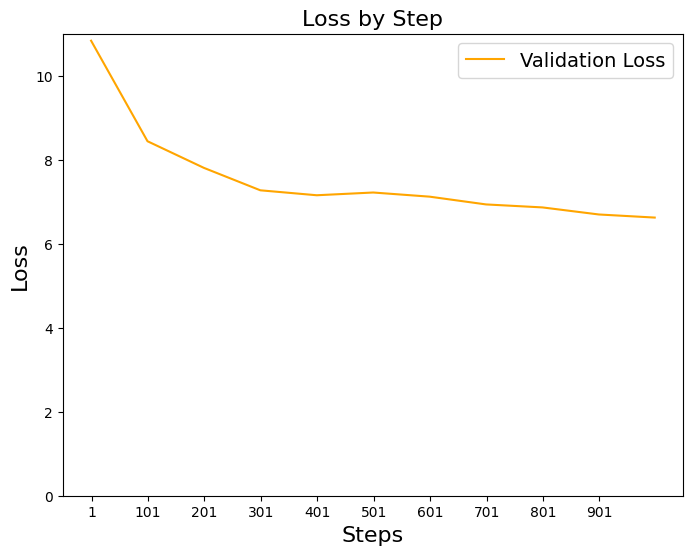

In [28]:
# Plot train and validation performance
tick_width = 100
train_steps, train_losses = zip(*training_loss)
val_steps, val_losses = zip(*validation_loss)
custom_ticks = range(min(train_steps), max(train_steps) + 1, tick_width)
plt.figure(figsize=(8, 6))
# plt.plot(train_steps, train_losses, label='Train Loss', color='blue')
plt.plot(val_steps, val_losses, label='Validation Loss', color='orange')
plt.xticks(custom_ticks)
plt.xlabel('Steps', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.ylim(0, 11)
plt.title('Loss by Step', fontsize=16)
plt.legend(fontsize=14)
plt.show()

This is a dummy run of "only" 1000 steps (we will do many, many more in the second phase!), used to check whether there are any bugs in our architecture. Since the validation loss seems to be decreasing, the architecture appears to be correct, and the results are promising.

## Why only show the validation loss?

In previous homework, we typically show the train and validation loss as well as the train and validation accuracy. Why only show the validation loss this time? There are good reasons for that.

We don't show accuracy because language modeling is essentially a classification problem with about 50,000 classes (50,000 tokens to choose from). A state of the art, large scale LLM may be able to predict exactly what the next token will be a good percentage of the time, but can't hope to achieve that with the compute resources that we have. Our "small scale LLM" might be able to generate plausible-sounding text, but in terms of accurately predicting the next word in a text, it will be wrong the vast majority of the time. Hence, accuracy is not a very relevant metric here. Entropy loss, however, is still a relevant metric: it describes how "surprised" the model is from seeing each correct next token.

We don't show training loss because it would not add much relevant information to the chart. Typically, the model iterates over the training loss over epochs. However, here, we are working with billions of tokens in the training set. Even the 1000 gradient steps we took above are a small fraction of the entire training set. That is, we are not even close to having completed one epoch. Hence, the training loss and validation loss are essentially the same thing, because in both cases, they reflect performance on data that the model has never seen before (again, since the model does not see the same training example twice). Since training and validation loss are essentially duplicative in this situation, we only show validation loss.  

Moreover, I initially was planning to look at the perplexity metric, which measures the "surprise" of a model on test data. This metric is commonly discussed when talking about languge model performance. However, I realized that perplexity is simply defined as exponential of cross-entropy loss. Since perplexity is monotonic with respect to cross-entropy loss, it would be redundant to look at both metrics to compare model runs, and so I focusd on cross-entropy loss only. I chose to focus only loss-only instead of entropy-only simply because loss is on a small scale and there is easier to plot and look at. The loss of my models range from 0 to 11 whereas the perplexity would range from 0 to exp(11) which is over 50,000!  


In the next phase of this project, we will train the model for many more steps, and we will test it's text generating abilities. We may also experiment with different hyperparameters to see what works best.

### References

[1] "FNSPID", Hugging Face, https://huggingface.co/datasets/Zihan1004/FNSPID/tree/main/Stock_news

[2] "Neural Networks: Zero to Hero", Andrej Karpathy, https://youtube.com/playlist?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&feature=shared

[3] "Attention Is All You Need", Vaswani et al., https://arxiv.org/abs/1706.03762